In [7]:
import numpy as np
import pysindy as ps
import matplotlib.pyplot as plt

Here I want to make an attempt to recover the logistic growth equation from the solution curve with noise injected.
The original ODE is 

$$\dot{N} = rN\left(1 - \frac{N}{k}\right)$$
Its solution for some $N(0) = N_0$ is

$$N(t) = \frac{Ake^{rt}}{1 + Ae^{rt}} \hspace{5pt}, \hspace{5pt} A = \frac{N_0}{k - N_0}$$

Where $r$ is the constant of proportionality and $k$ is the carrying capacity of the system. These are both constants I would need to supply. 

In [8]:
#Constants
N0 = 1 #Initial Population
k = 20 #Carrying Capacity
A = N0/(k - N0) # Simple Constant
r = 1 #Proportionality Constant

In [9]:
#Functions
def analytic_solution(t):
    return A*k*np.exp(r*t) / (1 + A*np.exp(r*t))

A plot of logistic growth from the analytical solution

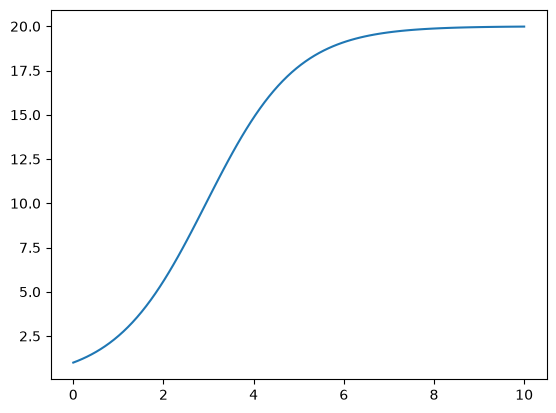

In [10]:
time_data = np.linspace(0,10,100)
solution_curve = analytic_solution(time_data)

plt.plot(time_data,solution_curve)
plt.show()

Setting up gaussian noise

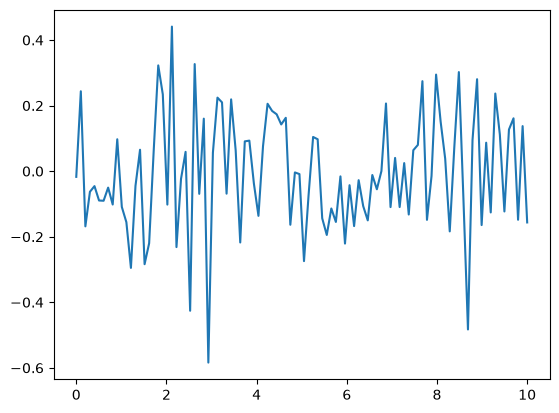

In [17]:
noise = np.random.normal(loc=0.0,scale = 0.2,size = time_data.size)
plt.plot(time_data,noise)
plt.show()

Now I will setup the model and see if it can recreate the ODE

In [ ]:
t = np.linspace(0,10,100)
N = analytic_solution(t) + noise
N = np.asarray(N).reshape(-1,1)

#Establish Methods

thresholds = [0.001, 0.005, 0.01, 0.02, 0.03, 0.05]


differentiation_method = ps.SmoothedFiniteDifference(order=2)
feature_library = ps.PolynomialLibrary(degree=3, include_bias=False)
#optimizer = ps.STLSQ(threshold=threshold,alpha = 0.0, verbose=False)
optimizer = ps.SR3(regularizer="l0", reg_weight_lam=0.0, verbose=True)

#Create Model
model = ps.SINDy(
    differentiation_method = differentiation_method,
    feature_library=feature_library,
    optimizer=optimizer,
)

#Fit and inspect model
model.fit(N,t=t, feature_names = ["N"])
model.print()

 Iteration ... |y - Xw|^2 ...  |w-u|^2/v ...       R(u) ... Total Error: |y-Xw|^2 + |w-u|^2/v + R(u)
         0 ... 1.1828e+01 ... 0.0000e+00 ... 0.0000e+00 ... 1.1828e+01
(N)' =  1.017 N + -0.052 N^2
